# LLM 기반 리뷰 분석

`02_review_bertopic_modeling.ipynb`에서 생성된 집계 JSON을 입력으로 받아 LLM을 활용합니다.

**LLM의 역할은 두 가지로만 제한합니다:**
1. BERTopic 토픽 키워드 → 카테고리 레이블 자동 부여 (bug / balance / price / performance / content / other)
2. 통계 집계 수치 기반 액션 제안 서술

**LLM이 하지 않는 것:**
- 리뷰 원문 직접 읽기
- 카테고리 건수 추정
- 주관적 판단으로 분류

**분석 흐름**
```
data/processed/review_analysis_summary_{appid}.json  ← 02_ 출력
    ↓
[LLM 1회 호출] 토픽 키워드 레이블링 + 집계 수치 기반 액션 제안 동시 처리
    ↓
카테고리별 비율 집계 (통계) + 액션 제안 출력
```

In [7]:
import os
import json
import platform
import warnings
import pandas as pd
import matplotlib.pyplot as plt
from google import genai
from google.genai import types
from dotenv import load_dotenv

warnings.filterwarnings('ignore')
load_dotenv()

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

client = genai.Client(api_key=os.getenv('GEMINI_API_KEY'))
MODEL = 'gemini-3-flash-preview'
print('라이브러리 로드 완료')

라이브러리 로드 완료


In [8]:
# 분석 대상 게임 설정
TARGET_APPID = 1214470

summary_path = f'../../../../data/processed/review_analysis_summary_{TARGET_APPID}.json'
with open(summary_path, 'r', encoding='utf-8') as f:
    summary = json.load(f)

print(f"[appid={TARGET_APPID}] 집계 데이터 로드 완료")
print(f"  전체 리뷰: {summary['total_reviews']:,}건")
print(f"  부정: {summary['negative']['count']}건 / 긍정: {summary['positive']['count']}건")
print(f"  부정 토픽 수: {len(summary['negative']['topics'])}개")
print(f"  긍정 토픽 수: {len(summary['positive']['topics'])}개")

[appid=1214470] 집계 데이터 로드 완료
  전체 리뷰: 969건
  부정: 237건 / 긍정: 732건
  부정 토픽 수: 2개
  긍정 토픽 수: 6개


## LLM 단일 호출: 레이블링 + 액션 제안

부정/긍정 토픽 키워드와 집계 수치를 하나의 프롬프트로 전달하여 1회 호출로 모두 처리합니다.

**출력 구조:**
- `neg_labels`: 부정 토픽 → 카테고리 매핑
- `pos_labels`: 긍정 토픽 → 카테고리 매핑
- `action_plan`: 집계 수치 기반 액션 제안 (즉시/단기/장기/강점 유지)

In [9]:
VALID_CATEGORIES = ['bug', 'balance', 'price', 'performance', 'content', 'other']

def build_prompt(summary: dict) -> str:
    def fmt_topics(topics):
        return '\n'.join(
            f'  - topic_id {t["topic_id"]} ({t["count"]}건): {", ".join(t["keywords"])}'
            for t in topics
        )

    return f"""아래는 Steam 인디게임(appid={summary['appid']}) 리뷰 분석 데이터입니다.

전체 리뷰: {summary['total_reviews']}건 (부정: {summary['negative']['count']}건 / 긍정: {summary['positive']['count']}건)

[부정 리뷰 BERTopic 토픽]
{fmt_topics(summary['negative']['topics'])}

[긍정 리뷰 BERTopic 토픽]
{fmt_topics(summary['positive']['topics'])}

다음 두 가지를 동시에 수행하세요.

1. 각 토픽을 카테고리로 분류하세요.
   허용 카테고리: bug, balance, price, performance, content, other

2. 부정/긍정 토픽 분포를 근거로 인디 게임 개발사에게 액션을 제안하세요.
   형식: 즉시 대응 / 단기 개선(1~2개월) / 장기 개선 / 유지·강화할 강점
   각 항목은 2~3개 bullet point로 간결하게 작성하세요.

반드시 아래 JSON 형식으로만 응답하세요 (다른 텍스트 없이):
{{
  "neg_labels": [{{"topic_id": <int>, "category": "<category>"}}],
  "pos_labels": [{{"topic_id": <int>, "category": "<category>"}}],
  "action_plan": {{
    "immediate": ["..."],
    "short_term": ["..."],
    "long_term": ["..."],
    "strengths": ["..."]
  }}
}}"""


def analyze(summary: dict) -> dict:
    prompt = build_prompt(summary)
    response = client.models.generate_content(
        model=MODEL,
        contents=prompt,
        config=types.GenerateContentConfig(
            response_mime_type='application/json',
            temperature=0.3,
        ),
    )
    return json.loads(response.text)


print('LLM 분석 중 (1회 호출)...')
result = analyze(summary)
print('완료!')

neg_labels = {item['topic_id']: item['category'] for item in result['neg_labels']}
pos_labels = {item['topic_id']: item['category'] for item in result['pos_labels']}
action_plan = result['action_plan']

print('\n부정 토픽 레이블:')
for tid, label in neg_labels.items():
    print(f'  topic {tid} → {label}')
print('\n긍정 토픽 레이블:')
for tid, label in pos_labels.items():
    print(f'  topic {tid} → {label}')

LLM 분석 중 (1회 호출)...
완료!

부정 토픽 레이블:
  topic 0 → bug
  topic 1 → performance

긍정 토픽 레이블:
  topic 0 → bug
  topic 1 → other
  topic 2 → content
  topic 3 → other
  topic 4 → content
  topic 5 → content


## 카테고리별 비율 집계 및 시각화

LLM이 부여한 레이블로 토픽 건수를 카테고리별로 집계합니다.

In [10]:
def aggregate_by_category(topics: list[dict], labels: dict[int, str], total_count: int) -> pd.DataFrame:
    rows = [
        {'category': labels.get(t['topic_id'], 'other'), 'count': t['count']}
        for t in topics
    ]
    df = pd.DataFrame(rows).groupby('category', as_index=False)['count'].sum()
    df['ratio(%)'] = (df['count'] / total_count * 100).round(1)
    return df.sort_values('count', ascending=False).reset_index(drop=True)


neg_cat_df = aggregate_by_category(summary['negative']['topics'], neg_labels, summary['negative']['count'])
pos_cat_df = aggregate_by_category(summary['positive']['topics'], pos_labels, summary['positive']['count'])

print('=== 부정 리뷰 카테고리 집계 ===')
display(neg_cat_df)
print('\n=== 긍정 리뷰 카테고리 집계 ===')
display(pos_cat_df)

=== 부정 리뷰 카테고리 집계 ===


,category,count,ratio(%)
0,bug,204,86.1
1,performance,21,8.9



=== 긍정 리뷰 카테고리 집계 ===


,category,count,ratio(%)
0,bug,308,42.1
1,other,189,25.8
2,content,164,22.4


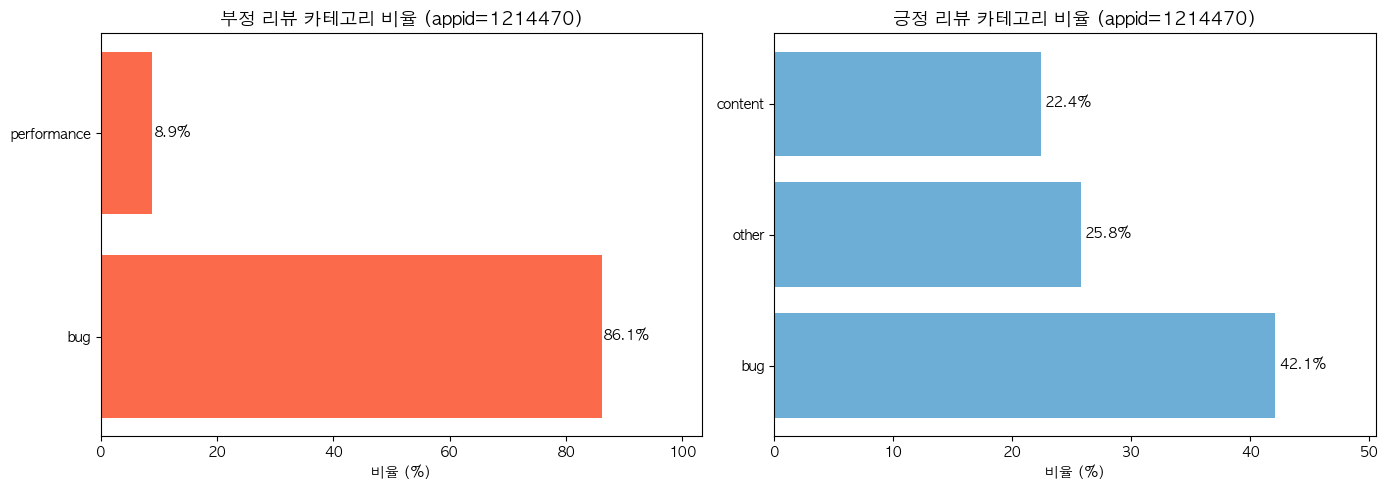

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title, color in [
    (axes[0], neg_cat_df, '부정 리뷰 카테고리 비율', 'Reds_r'),
    (axes[1], pos_cat_df, '긍정 리뷰 카테고리 비율', 'Blues_r'),
]:
    bars = ax.barh(df['category'], df['ratio(%)'], color=plt.cm.get_cmap(color)(0.5))
    ax.set_xlabel('비율 (%)')
    ax.set_title(f'{title} (appid={TARGET_APPID})', fontsize=13)
    for bar, val in zip(bars, df['ratio(%)']):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                f'{val}%', va='center', fontsize=10)
    ax.set_xlim(0, df['ratio(%)'].max() * 1.2)

plt.tight_layout()
plt.show()

## 액션 제안 출력

LLM이 토픽 분포를 근거로 생성한 개발사 액션 제안입니다.

In [12]:
labels_kr = {
    'immediate': '즉시 대응',
    'short_term': '단기 개선 (1~2개월)',
    'long_term': '장기 개선',
    'strengths': '유지·강화할 강점',
}

print(f'\n{"=" * 70}')
print(f'  개발사 액션 제안 (appid={TARGET_APPID})')
print(f'{"=" * 70}')
for key, label in labels_kr.items():
    print(f'\n[{label}]')
    for item in action_plan.get(key, []):
        print(f'  • {item}')


  개발사 액션 제안 (appid=1214470)

[즉시 대응]
  • 로딩 화면 멈춤 및 게임 크래시(튕김) 현상에 대한 긴급 패치 진행
  • 방, 바닥, 가구 배치 시 발생하는 주요 기능적 버그 우선 해결

[단기 개선 (1~2개월)]
  • 가구 배치 및 방 인식 시스템의 물리 엔진 안정성 개선
  • 부정적 리뷰에서 반복 언급되는 가구 관련 상호작용 폴리싱

[장기 개선]
  • House Flipper 등 유사 장르 선호 유저를 위한 심화된 호텔 디자인 콘텐츠 확장
  • 게임의 강점인 '힐링' 요소를 극대화할 수 있는 편의 기능 및 시각적 요소 추가

[유지·강화할 강점]
  • 호텔 리노베이션이라는 차별화된 핵심 게임 루프와 디자인 재미
  • 유저들이 높게 평가하는 특유의 여유롭고 편안한(Relaxing) 게임 분위기


**해석:** LLM 입력은 토픽 키워드와 건수 수치로만 구성됩니다.
카테고리 레이블링과 액션 제안이 1회 호출로 처리되며, 액션 제안의 근거는 토픽별 건수 분포입니다.
`other`로 분류된 토픽 비율이 높다면 BERTopic의 `min_cluster_size` 파라미터 조정을 검토하세요.